# 🧪 A/B Test Calculator - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/ab-test-calc/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/ab-test-calc/demo.ipynb)

> *"We eyeball significance instead of calculating."*

A variant "looking higher" means nothing without a test. This runs a proper
**two-proportion z-test** - p-value, confidence interval, clear verdict - plus a
**sample-size planner** so you know how much traffic you need before you start.

**What we cover**
1. The z-test, from scratch
2. A "looks like a win" that isn't significant
3. Real noise vs a real effect
4. How much traffic do you need?
5. Visualize rates + the confidence interval


## Step 1 - The two-proportion z-test

Pooled standard error for the test, unpooled for the confidence interval. The
p-value is two-sided.


In [1]:
from __future__ import annotations
import math
from dataclasses import dataclass
from scipy import stats

def run_ab_test(control_n, control_conv, variant_n, variant_conv, alpha=0.05):
    p1 = control_conv/control_n; p2 = variant_conv/variant_n
    abs_diff = p2 - p1
    rel_lift = (abs_diff/p1*100) if p1>0 else float("inf")
    pooled = (control_conv+variant_conv)/(control_n+variant_n)
    se_pooled = math.sqrt(pooled*(1-pooled)*(1/control_n+1/variant_n))
    z = abs_diff/se_pooled if se_pooled>0 else 0.0
    p_value = 2*(1-stats.norm.cdf(abs(z)))
    se_diff = math.sqrt(p1*(1-p1)/control_n + p2*(1-p2)/variant_n)
    zc = stats.norm.ppf(1-alpha/2)
    return {"control_rate":p1,"variant_rate":p2,"abs_diff":abs_diff,"rel_lift":rel_lift,
            "z":z,"p_value":p_value,"significant":p_value<alpha,
            "ci":(abs_diff-zc*se_diff, abs_diff+zc*se_diff)}

r = run_ab_test(5000, 500, 5000, 600)   # 10% vs 12%
print(f"control {r['control_rate']:.1%}  variant {r['variant_rate']:.1%}  "
      f"lift {r['rel_lift']:+.0f}%  p={r['p_value']:.4f}  significant={r['significant']}")

control 10.0%  variant 12.0%  lift +20%  p=0.0014  significant=True


## Step 2 - "Looks like a win" that isn't (the trap)

500/5000 vs 560/5000 is a +12% relative lift - tempting to ship. But the p-value is
**0.051**, just over 0.05. Not significant. This is exactly the eyeball mistake.


In [2]:
r = run_ab_test(5000, 500, 5000, 560)
print(f"variant is +{r['rel_lift']:.0f}% relative... but p = {r['p_value']:.4f}")
print("verdict:", "SHIP" if r["significant"] else "NOT YET - could be noise")

variant is +12% relative... but p = 0.0513
verdict: NOT YET - could be noise


## Step 3 - Real noise vs a real effect

In [3]:
cases = {
    "pure noise (500 vs 505)": run_ab_test(5000, 500, 5000, 505),
    "clear win   (500 vs 620)": run_ab_test(5000, 500, 5000, 620),
}
for name, r in cases.items():
    print(f"{name}: p={r['p_value']:.4f}  -> {'SIGNIFICANT' if r['significant'] else 'not significant'}")

pure noise (500 vs 505): p=0.8679  -> not significant
clear win   (500 vs 620): p=0.0001  -> SIGNIFICANT


## Step 4 - How much traffic do you need?

Don't start a test you can't power. This says how many visitors per variant you need
to detect a given lift.


In [4]:
def required_sample_size(baseline_rate, mde_abs, alpha=0.05, power=0.8):
    p1 = baseline_rate; p2 = min(max(baseline_rate+mde_abs,1e-9),1-1e-9)
    za = stats.norm.ppf(1-alpha/2); zp = stats.norm.ppf(power)
    pbar = (p1+p2)/2
    num = (za*math.sqrt(2*pbar*(1-pbar)) + zp*math.sqrt(p1*(1-p1)+p2*(1-p2)))**2
    return int(math.ceil(num/(mde_abs**2)))

for mde in (0.01, 0.02, 0.03):
    print(f"detect +{mde*100:g}pp on a 10% baseline -> {required_sample_size(0.10, mde):,} per variant")

detect +1pp on a 10% baseline -> 14,751 per variant
detect +2pp on a 10% baseline -> 3,841 per variant
detect +3pp on a 10% baseline -> 1,774 per variant


## Step 5 - Visualize rates + confidence interval

The error bar is the 95% CI on the difference, drawn on the variant. If it crosses
the control line, you can't call it.


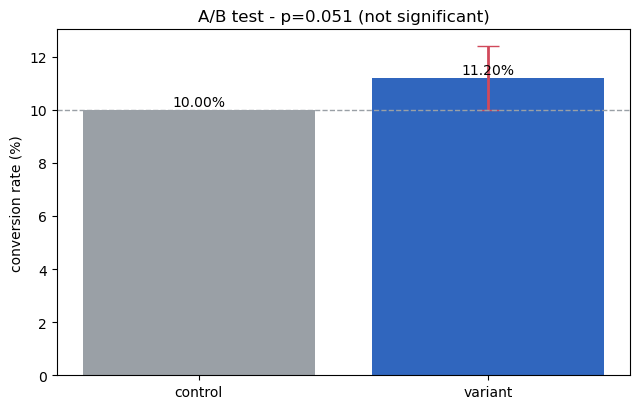

In [5]:
import matplotlib.pyplot as plt

r = run_ab_test(5000, 500, 5000, 560)   # the borderline case
groups = ["control", "variant"]
rates = [r["control_rate"]*100, r["variant_rate"]*100]
half = (r["ci"][1]-r["ci"][0])/2*100

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(groups, rates, color=["#9aa0a6", "#3066be"])
ax.errorbar(1, rates[1], yerr=half, fmt="none", ecolor="#d1495b", capsize=8, lw=2)
ax.axhline(rates[0], ls="--", c="#9aa0a6", lw=1)
for b, v in zip(bars, rates):
    ax.text(b.get_x()+b.get_width()/2, v+0.15, f"{v:.2f}%", ha="center")
ax.set_ylabel("conversion rate (%)")
ax.set_title(f"A/B test - p={r['p_value']:.3f} ({'significant' if r['significant'] else 'not significant'})")
plt.tight_layout(); plt.savefig("abtest.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- A proper **two-proportion z-test** gives a p-value + CI, not a guess.
- A big *relative* lift can still be **not significant** (the 0.051 trap).
- **Power your test first**: the sample-size planner tells you the traffic you need.

This is the engine behind the Streamlit app in `app.py`.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the calculator:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
